# RL Integ/Lead Design (11-7)

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [188]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

from matplotlib.lines import Line2D
lines_color=['m','c','b']
lines_shape=['s','d','x']
lines_text=['Target', 'CLP', 'OLP', ]

source = "./"

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

In [189]:

def writefile(filename, Gc): 
    '''
    Write Gc in text so that latex can read it
    '''
    # Write the zero of the transfer function to a file
    with open(filename+"_zero.txt", "w") as f:
        f.write(str(f"{np.real(-Gc.zeros())[0]:4.3f}"))
    
    # Write the pole of the transfer function to a file
    with open(filename+"_pole.txt", "w") as f:
        f.write(str(f"{np.real(-Gc.poles())[0]:4.3f}"))
    
    # Write the gain of the transfer function to a file
    with open(filename+"_gain.txt", "w") as f:
        f.write(str(f"{Gc.dcgain():4.2f}"))

In [190]:
G = ct.tf((0, 10), np.convolve((1,5),(1,10)))
# Goals
Mp = 0.2 # (1-zeta/0.6)
Ts = 1
# Ramp error
Kv_req = 1/0.05
#
zeta = np.sqrt(np.log(Mp)**2/(np.pi**2+np.log(Mp)**2))
wn = 4/zeta/Ts # 2%
sigma = zeta*wn
wd = wn*np.sqrt(1-zeta**2)

# Target Poles
s0 = np.roots([1, 2*zeta*wn, wn**2])

cm.pretty_row_print(s0,"Target poles: ")
print(f"{zeta = :.3f}")
print(f"{wn = :.3f}")
print(f"{wd = :.3f}")
print(f"{sigma = :.3f}")

Target poles: (-4.00 + 7.81i), (-4.00 + -7.81i)
zeta = 0.456
wn = 8.773
wd = 7.808
sigma = 4.000


In [191]:
# Need an integrator for zero SS error to step
# gain 10 seems reasonable
K_design = 10
Gc_int = K_design*ct.tf((1), (1, 0))
L_int = G*Gc_int


Found break-in/out at K =  0.481
At possible locations s = -2.113


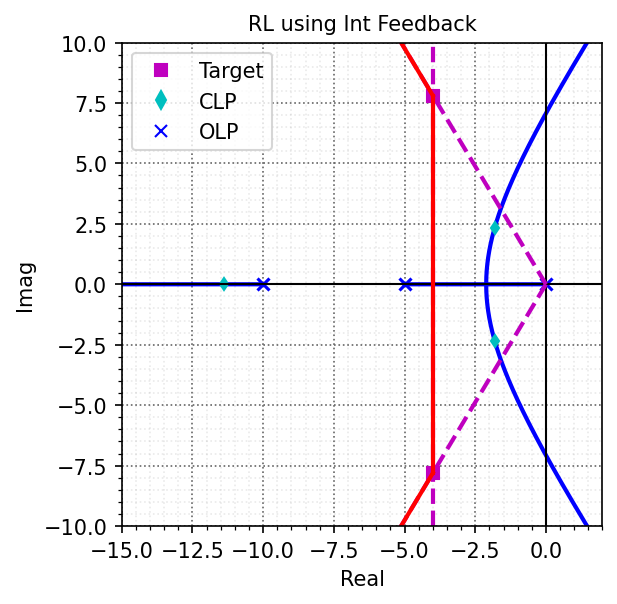

In [192]:
fig, ax = plt.subplots(figsize=(4, 4),dpi=150,constrained_layout = True)
ct.rlocus(L_int,ax=ax,gains=cm.Root_Locus_gains(L_int),color='b')
scl = ct.feedback(L_int).poles()

ax.plot(s0.real,s0.imag,lines_color[0]+lines_shape[0],ms=6)
ax.plot(scl.real,scl.imag,lines_color[1]+lines_shape[1],ms=4)
ax.set_xlim([-15, 2])
ax.set_ylim([-10, 10])
ax.set_title('Root Locus Using Int')
plt.suptitle("")
ax.set_xlabel('Real')
ax.set_ylabel('Imag')
bm.nicegrid(ax,-1)
cm.plot_spec_region(ax, zeta, wn, wd)

# Add legend with custom handles
custom_lines = [Line2D([0], [0],color=c,marker=m,label=t,linestyle='None',markersize=6) 
                for c, m, t in zip(lines_color, lines_shape, lines_text)]
ax.legend(handles=custom_lines)

plt.title("RL using Int Feedback")
plt.savefig("./figs/L13_RL_des1.pdf", dpi=600)
plt.show()

In [193]:
# Add lead with zero at -4
Gc_lead, scl,info = cm.Root_Locus_design_cancel(L_int, s_target = s0[0], s_cancel = -4)
Gain = cm.hf_gain(Gc_lead)
print(f"Gain {Gain:.3f}")
print(f"Lead zero s = {Gc_lead.zeros()[0].real :.3f}")
print(f"Lead pole s = {Gc_lead.poles()[0].real :.3f}")

cm.show_tf_latex(Gc_lead*Gc_int,show=True,label=r"G_c^{lead}(s)",factor=True,sigfigs=2)
cm.write_tf_latex(Gc_lead*Gc_int,label=r"G_c^{lead}(s)",factor=True,filename="Gc_11_9.tex",sigfigs=5)


Gain 22.351
Lead zero s = -4.000
Lead pole s = -28.447


<IPython.core.display.Math object>

Current Kv = 6.286

Found break-in/out at K =  0.136
At possible locations s = -6.757


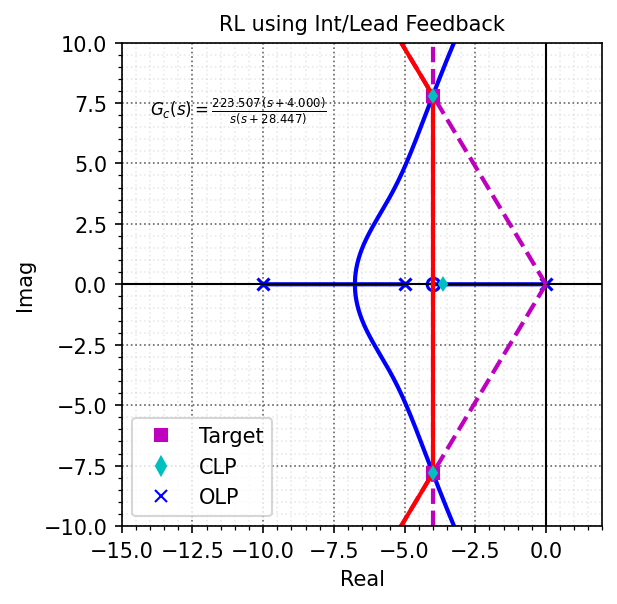

In [194]:
L_int_lead = G*Gc_int*Gc_lead
Kv_int_lead = cm.find_Kv(L_int_lead)

print(r'Current Kv = {:5.3f}'.format(Kv_int_lead))

consts = {"gain": cm.hf_gain(Gc_lead),
        "Kv": Kv_int_lead,
        "St": np.abs(s0[0]),
        }
cm.write_latex_constants(consts, filename="./figs/constants_11_11.tex", idname="El")

fig, ax = plt.subplots(figsize=(4, 4),dpi=150,constrained_layout = True)
ct.rlocus(L_int_lead,ax=ax,gains=cm.Root_Locus_gains(L_int_lead),color='b')
scl = ct.feedback(L_int_lead).poles()

ax.plot(s0.real,s0.imag,lines_color[0]+lines_shape[0],ms=6)
ax.plot(scl.real,scl.imag,lines_color[1]+lines_shape[1],ms=4,zorder=10)
ax.set_xlim([-15, 2])
ax.set_ylim([-10, 10])
ax.set_xlabel('Real')
ax.set_ylabel('Imag')
ax.set_title('Root Locus Using Int/Lead')
plt.suptitle("")
bm.nicegrid(ax,-1)
cm.plot_spec_region(ax, zeta, wn, wd)
# Add legend with custom handles
custom_lines = [Line2D([0], [0],color=c,marker=m,label=t,linestyle='None',markersize=6) 
                for c, m, t in zip(lines_color, lines_shape, lines_text)]
ax.legend(handles=custom_lines)

msgs = cm.show_tf_latex(Gc_int*Gc_lead,label="G_c(s)",factor=True,sigfigs=3)
ax.text(-14,7,msgs,fontsize=8)

plt.title("RL using Int/Lead Feedback")
plt.savefig("./figs/L13_RL_des2.pdf", dpi=600)
plt.show()

In [195]:
# Pole locations good - Kv req met?
gamma = 10
b = abs(s0[0])/gamma
a = b / (Kv_req / Kv_int_lead)
Gc_lag = ct.tf((1, b), (1, a))

#writefile(source+"Gc_11_11", Gc_lag)

cm.show_tf_latex(Gc_lag,show=True,label=r"G_c^{lag}(s)",factor=True,sigfigs=3)
cm.write_tf_latex(Gc_int,label=r"G_c^{int}(s)",factor=True,filename="Gc_11_11_0.tex",sigfigs=5,inline=True)
cm.write_tf_latex(Gc_lead,label=r"G_c^{lead}(s)",factor=True,filename="Gc_11_11_1.tex",sigfigs=5,inline=True)
cm.write_tf_latex(Gc_lag,label=r"G_c^{lag}(s)",factor=True,filename="Gc_11_11_2.tex",sigfigs=5,inline=True)


<IPython.core.display.Math object>


Found break-in/out at K =  0.149
At possible locations s = -6.706

Found break-in/out at K =  0.419
At possible locations s = -1.639

Found break-in/out at K =  0.004
At possible locations s = -0.150


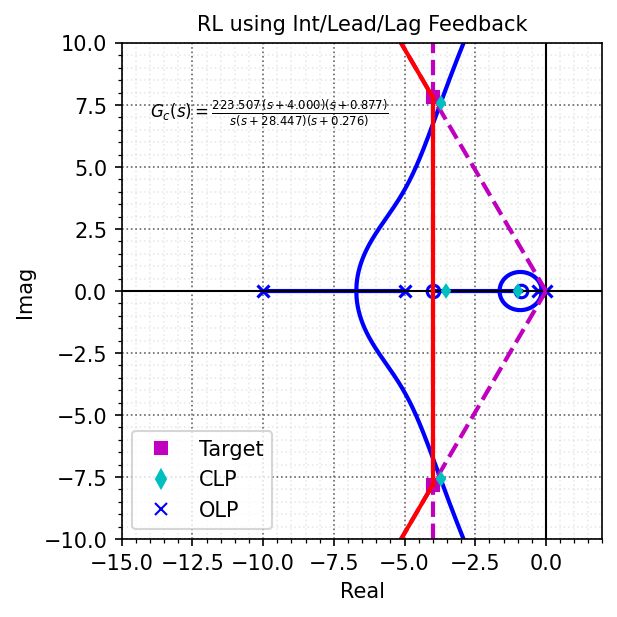

In [196]:
L_full = G*Gc_int*Gc_lead*Gc_lag

fig, ax = plt.subplots(figsize=(4, 4),dpi=150,constrained_layout = True)
ct.rlocus(L_full,ax=ax,gains=cm.Root_Locus_gains(L_full),color='b')
scl = ct.feedback(L_full).poles()

ax.plot(s0.real,s0.imag,lines_color[0]+lines_shape[0],ms=6)
ax.plot(scl.real,scl.imag,lines_color[1]+lines_shape[1],ms=4,zorder=10)
ax.set_xlim([-15, 2])
ax.set_ylim([-10, 10])
ax.set_xlabel('Real')
ax.set_ylabel('Imag')
ax.set_title('Root Locus Using Int/Lead/Lag')
bm.nicegrid(ax)
cm.plot_spec_region(ax, zeta, wn, wd)
# Add legend with custom handles
custom_lines = [Line2D([0], [0],color=c,marker=m,label=t,linestyle='None',markersize=6) 
                for c, m, t in zip(lines_color, lines_shape, lines_text)]
ax.legend(handles=custom_lines)

msgs = cm.show_tf_latex(Gc_int*Gc_lag*Gc_lead,label="G_c(s)",factor=True,sigfigs=3)
ax.text(-14,7,msgs,fontsize=8)

plt.title("RL using Int/Lead/Lag Feedback")
plt.savefig("./figs/L13_RL_des3.pdf", dpi=600)
plt.show()

## Since adding Lag impacted closed-loop poles locations, <br> redesign Lead to compensate for this Lag effect

Gain = 28.894
Iterated Lead zero s = -4.000
Iterated Lead pole s = -35.291
Current Kv = 20.841

Found break-in/out at K =  0.152
At possible locations s = -6.742

Found break-in/out at K =  0.407
At possible locations s = -1.631

Found break-in/out at K =  0.004
At possible locations s = -0.150


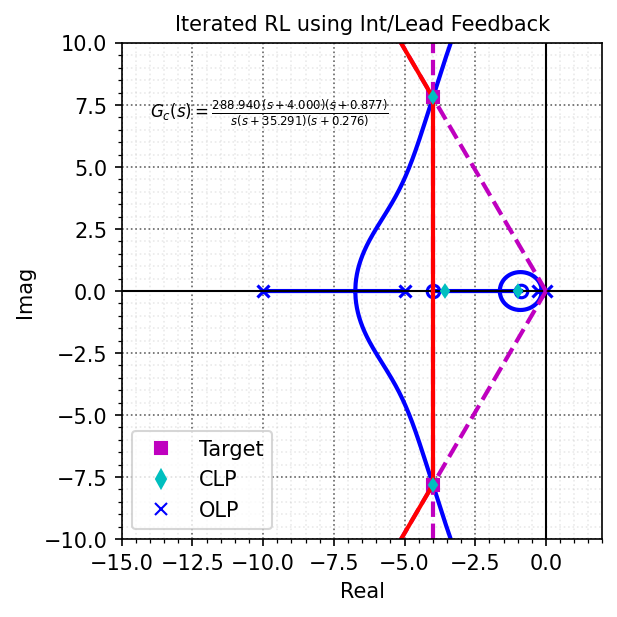

In [197]:
## Add lead with zero at -4
# now we design the lead including the lag compensator   
L_iter = G*Gc_int*Gc_lag
Gc_lead3_iter, scl3_iter,info = cm.Root_Locus_design_cancel(L_iter,s_target = s0[0], s_cancel = -4)
Gain = cm.hf_gain(Gc_lead3_iter)
print(f"{Gain = :.3f}")
print(f"Iterated Lead zero s = {Gc_lead3_iter.zeros()[0].real :.3f}")
print(f"Iterated Lead pole s = {Gc_lead3_iter.poles()[0].real :.3f}")

L_full3_iter = L_iter*Gc_lead3_iter
Kv_full3_iter = cm.find_Kv(L_full3_iter)
print(r'Current Kv = {:5.3f}'.format(Kv_full3_iter))

fig, ax = plt.subplots(figsize=(4, 4),dpi=150,constrained_layout = True)
ct.rlocus(L_full3_iter,ax=ax,gains=cm.Root_Locus_gains(L_full3_iter),color='b')
scl3_iter = ct.feedback(L_full3_iter,1).poles()

ax.plot(s0.real,s0.imag,lines_color[0]+lines_shape[0],ms=6)
ax.plot(scl3_iter.real,scl3_iter.imag,lines_color[1]+lines_shape[1],ms=4,zorder=10)
ax.set_xlim([-15, 2])
ax.set_ylim([-10, 10])
ax.set_xlabel('Real')
ax.set_ylabel('Imag')
ax.set_title('Root Locus Using Int/Lead/Lag')
bm.nicegrid(ax)
cm.plot_spec_region(ax, zeta, wn, wd)
# Add legend with custom handles
custom_lines = [Line2D([0], [0],color=c,marker=m,label=t,linestyle='None',markersize=6) 
                for c, m, t in zip(lines_color, lines_shape, lines_text)]
ax.legend(handles=custom_lines)

msgs = cm.show_tf_latex(Gc_int*Gc_lag*Gc_lead3_iter,label="G_c(s)",factor=True,sigfigs=3)
ax.text(-14,7,msgs,fontsize=8)

plt.title("Iterated RL using Int/Lead Feedback")
plt.savefig("./figs/L13_RL_des3_iter.pdf", dpi=600)
plt.show()

omega_n:	7.486
zeta   :	0.413
Tr     :	0.19s
Ts     :	1.59s
Mp     :	0.24
Tp     :	0.46s
Yss    :	1.01


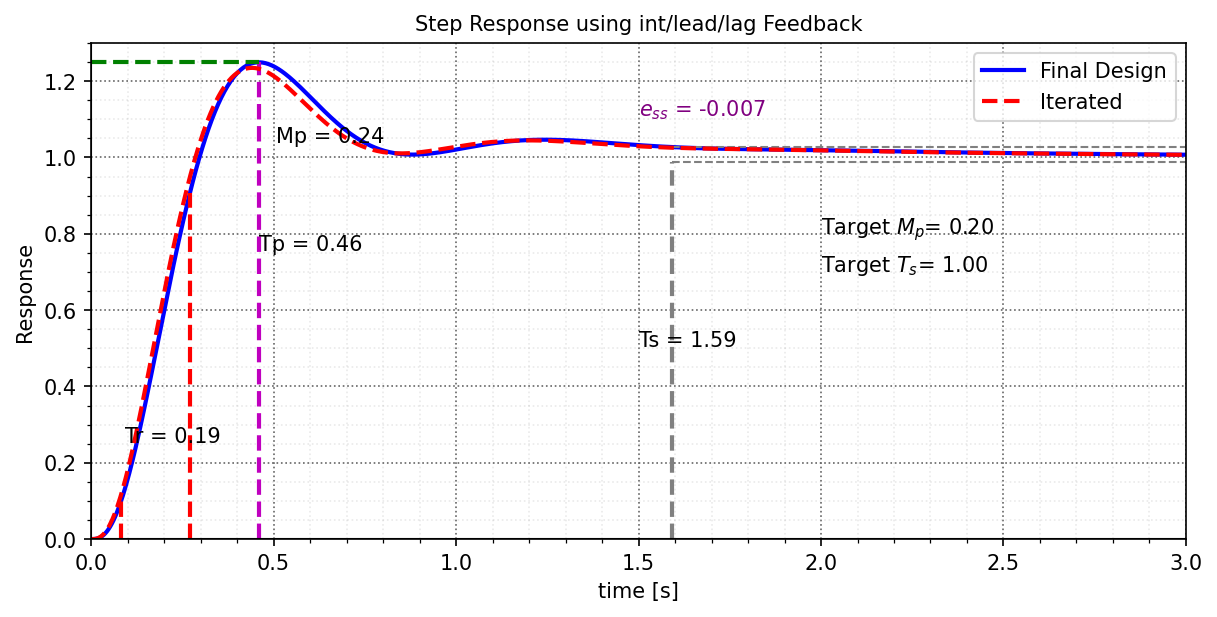

In [198]:
Gcl_full = ct.feedback(L_full,1)
y_full,t_full = cmat.step(Gcl_full,3)

try: # was the iteration done?
    Gcl_full3 = ct.feedback(L_full3_iter,1)
    y_full3,t_full3 = cmat.step(Gcl_full3,3)
    iterated = True 
except:
    iterated = False 

fig, ax = plt.subplots(1,figsize=(8, 4),dpi=150,constrained_layout = True)
S_full = cm.Step_info(t_full,y_full)
S_full.printout()
S_full.nice_plot(ax)
if iterated:
    plt.plot(t_full3,y_full3,'r--',label='Iterated')
bm.nicegrid(ax,-1)
# Create custom legend handles
custom_lines = [
    Line2D([0], [0], color='blue', lw=2, linestyle='-'),
    Line2D([0], [0], color='red', lw=2, linestyle='--'),
]
# Add legend with custom handles
ax.legend(custom_lines, ['Final Design', 'Iterated'])

ax.text(Ts+1,0.8,f'Target $M_p$= {Mp:.2f}')
ax.text(Ts+1,0.7,f'Target $T_s$= {Ts:.2f}')

plt.title("Step Response using int/lead/lag Feedback")
plt.savefig("./figs/L13_RL_des4.pdf", dpi=600)
plt.show()

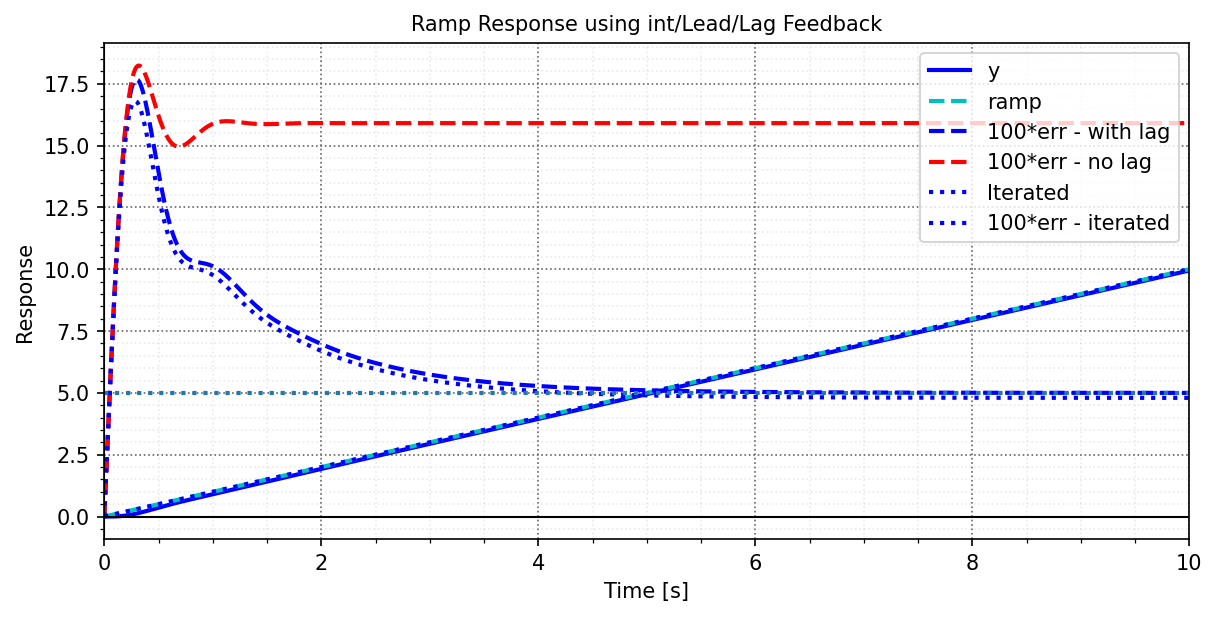

In [199]:
t = np.linspace(0,10,1000)
Gcl_IL = ct.feedback(L_int_lead,1)
y_IL_ramp, t_IL_ramp, x_IL_ramp = cmat.lsim(ct.tf2ss(Gcl_IL), T=t, U=t)
y_full_ramp, t_full_ramp, x_full_ramp = cmat.lsim(ct.tf2ss(Gcl_full), T=t, U=t)

fig, ax = plt.subplots(figsize=(8, 4),dpi=150,constrained_layout = True)
plt.plot(t_full_ramp,y_full_ramp,'b-',label='y')
plt.plot(t_full_ramp,t_full_ramp,'c--',label='ramp')
plt.plot(t_full_ramp,100*(t_full_ramp - y_full_ramp),'b--',label='100*err - with lag')
plt.plot(t_IL_ramp,100*(t_IL_ramp - y_IL_ramp),'r--',label='100*err - no lag')
if iterated:
    y_full3_ramp, t_full3_ramp, x_full3_ramp = cmat.lsim(ct.tf2ss(Gcl_full3), T=t, U=t)
    plt.plot(t_full3_ramp,t_full3_ramp,'b:',label='Iterated')
    plt.plot(t_full3_ramp,100*(t_full3_ramp - y_full3_ramp),'b:',label='100*err - iterated')
plt.axhline(y=100/Kv_req,ls=':')
bm.nicegrid(ax,-1)
plt.title("Ramp")
plt.xlabel("Time [s]")
plt.ylabel("Response")
plt.legend()
plt.title("Ramp Response using int/Lead/Lag Feedback")
plt.savefig("./figs/L13_RL_des5.pdf", dpi=600)
plt.show()